In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, string

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [2]:
df=pd.read_csv('imdb_sentiment_data.csv')
df

,review,sentiment,sentiment_label
0,This movie was so bad that I am struggling to ...,0,negative
1,The worst film I have seen all year without an...,0,negative
2,This is hands down the worst movie I have seen...,0,negative
3,The world building in this movie was absolutel...,1,positive
4,An emotionally rich film that resonated with m...,1,positive
...,...,...,...
95,This movie had so much potential but failed on...,0,negative
96,The director clearly had no vision for what th...,0,negative
97,This film made me laugh cry and feel everythin...,1,positive
98,A chaotic mess of a movie with no clear direct...,0,negative


In [3]:
df.shape

(100, 3)

In [4]:
df.columns

Index(['review', 'sentiment', 'sentiment_label'], dtype='str')

In [5]:
df['sentiment_label'].value_counts().to_dict()
df.head()

,review,sentiment,sentiment_label
0,This movie was so bad that I am struggling to ...,0,negative
1,The worst film I have seen all year without an...,0,negative
2,This is hands down the worst movie I have seen...,0,negative
3,The world building in this movie was absolutel...,1,positive
4,An emotionally rich film that resonated with m...,1,positive


In [6]:
VOCAB_SIZE = 10_000
MAX_LEN    = 200

(X_imdb_train, y_imdb_train), (X_imdb_test, y_imdb_test) = \
    keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("IMDB train:", X_imdb_train.shape, "| test:", X_imdb_test.shape)
print("Sample review (encoded):", X_imdb_train[0][:15], "...")

# Decode back to text (for display)
word_index = keras.datasets.imdb.get_word_index()
idx2word   = {v+3: k for k, v in word_index.items()}
idx2word.update({0:"<PAD>", 1:"<START>", 2:"<UNK>", 3:"<UNUSED>"})
decoded = " ".join(idx2word.get(i, "?") for i in X_imdb_train[0][:40])
print("\nDecoded sample:", decoded)

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


IMDB train: (25000,) | test: (25000,)
Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...

Decoded sample: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came


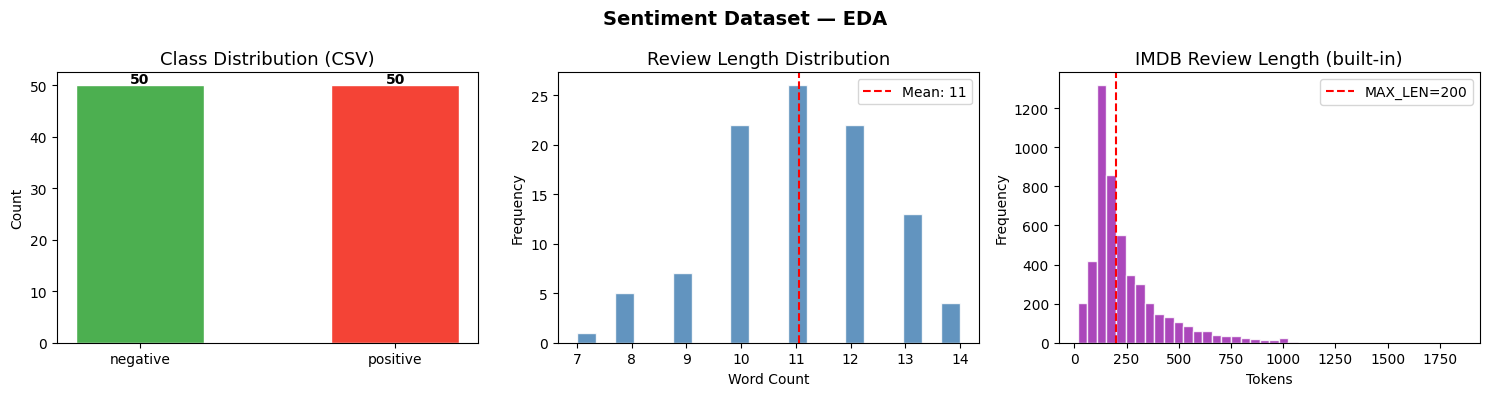

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df['sentiment_label'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution (CSV)', fontsize=13)
axes[0].set_ylabel('Count')
for i, (lbl, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold')

# 2. Review length distribution
df['review_len'] = df['review'].apply(lambda x: len(x.split()))
axes[1].hist(df['review_len'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Review Length Distribution', fontsize=13)
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('Frequency')
axes[1].axvline(df['review_len'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['review_len'].mean():.0f}")
axes[1].legend()

# 3. IMDB review length distribution
imdb_lens = [len(x) for x in X_imdb_train[:5000]]
axes[2].hist(imdb_lens, bins=40, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[2].set_title('IMDB Review Length (built-in)', fontsize=13)
axes[2].set_xlabel('Tokens'); axes[2].set_ylabel('Frequency')
axes[2].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[2].legend()

plt.suptitle('Sentiment Dataset — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

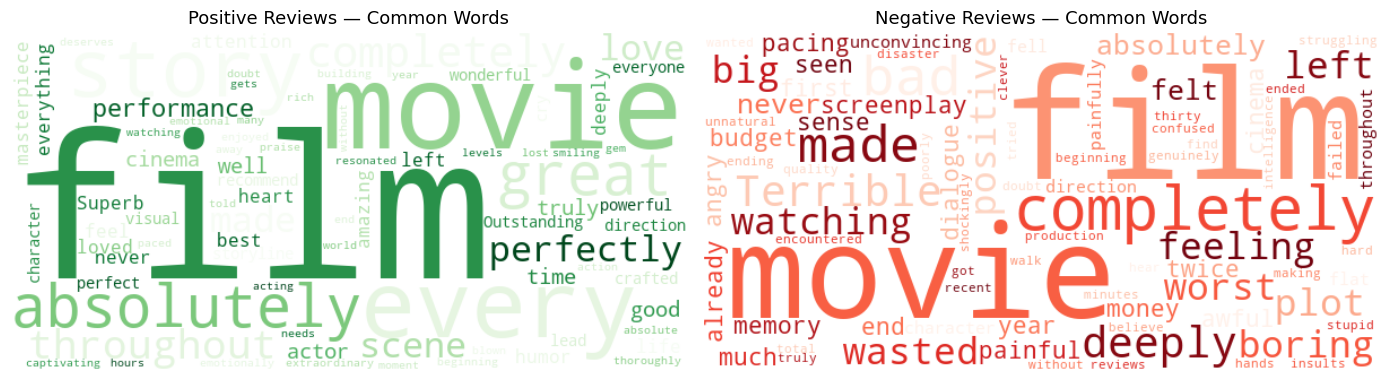

✅ WordCloud saved!


In [8]:
# WordCloud — positive vs negative words
try:
    from wordcloud import WordCloud

    pos_text = " ".join(df[df['sentiment']==1]['review'].values)
    neg_text = " ".join(df[df['sentiment']==0]['review'].values)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, text, title, cmap in zip(
            axes,
            [pos_text, neg_text],
            ['Positive Reviews — Common Words', 'Negative Reviews — Common Words'],
            ['Greens', 'Reds']):
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap, max_words=80).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(title, fontsize=13); ax.axis('off')

    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ WordCloud saved!")
except ImportError:
    print("WordCloud not installed — skip: pip install wordcloud")


In [9]:
# ── 4A : Clean text function ────────────────────────────────────────────────
def clean_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'<.*?>', '', text)                    # HTML tags remove
    text = re.sub(r'http\S+|www\.\S+', '', text)       # URLs remove
    text = text.translate(str.maketrans('','', string.punctuation))  # punctuation
    text = re.sub(r'\d+', '', text)                      # numbers
    text = re.sub(r'\s+', ' ', text).strip()             # extra spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)

print("Original  :", df['review'].iloc[0][:80])
print("Cleaned   :", df['clean_review'].iloc[0][:80])
print("\n✅ Text cleaning done!")


Original  : This movie was so bad that I am struggling to find any positives
Cleaned   : this movie was so bad that i am struggling to find any positives

✅ Text cleaning done!


In [10]:
# ── 4B : Tokenize + Pad Sequences (CSV data) ────────────────────────────────
CSV_VOCAB  = 5000
CSV_MAXLEN = 50

tokenizer = Tokenizer(num_words=CSV_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_review'])

sequences  = tokenizer.texts_to_sequences(df['clean_review'])
padded     = pad_sequences(sequences, maxlen=CSV_MAXLEN, padding='post', truncating='post')
labels_arr = np.array(df['sentiment'])

print(f"Vocabulary size : {len(tokenizer.word_index):,} unique words")
print(f"Padded shape    : {padded.shape}")
print(f"Sample sequence : {padded[0][:15]}")

# Train-Test split (CSV)
X_csv_train, X_csv_test, y_csv_train, y_csv_test = train_test_split(
    padded, labels_arr, test_size=0.2, random_state=42, stratify=labels_arr)

print(f"\nTrain : {X_csv_train.shape} | Test : {X_csv_test.shape}")
print("✅ Tokenization done!")


Vocabulary size : 430 unique words
Padded shape    : (100, 50)
Sample sequence : [  4   8   5  25  22   9  10 148 149  12 150  26 151   0   0]

Train : (80, 50) | Test : (20, 50)
✅ Tokenization done!


In [11]:
# ── 4C : Pad IMDB sequences ─────────────────────────────────────────────────
X_imdb_train_pad = pad_sequences(X_imdb_train, maxlen=MAX_LEN,
                                  padding='post', truncating='post')
X_imdb_test_pad  = pad_sequences(X_imdb_test,  maxlen=MAX_LEN,
                                  padding='post', truncating='post')

print("IMDB train padded :", X_imdb_train_pad.shape)
print("IMDB test  padded :", X_imdb_test_pad.shape)
print("✅ IMDB padding done!")


IMDB train padded : (25000, 200)
IMDB test  padded : (25000, 200)
✅ IMDB padding done!


In [12]:
# ── Model A : Simple LSTM (CSV data pe train) ───────────────────────────────
def build_lstm(vocab_size, maxlen, embed_dim=64, lstm_units=64, name='LSTM_Model'):
    model = keras.Sequential([
        layers.Input(shape=(maxlen,)),
        layers.Embedding(vocab_size, embed_dim, mask_zero=True),
        layers.SpatialDropout1D(0.2),
        layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
                                          dropout=0.2, recurrent_dropout=0.2)),
        layers.Bidirectional(layers.LSTM(lstm_units // 2,
                                          dropout=0.2, recurrent_dropout=0.2)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name=name)
    return model

# CSV model (small vocab)
model_csv = build_lstm(CSV_VOCAB, CSV_MAXLEN, embed_dim=32,
                        lstm_units=32, name='LSTM_CSV')
model_csv.summary()


Model: "LSTM_CSV"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 64)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,185 (739.00 KB)

 Trainable params: 189,185 (739.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── Model B : Deeper LSTM (IMDB 25k pe train) ────────────────────────────────
model_imdb = build_lstm(VOCAB_SIZE, MAX_LEN, embed_dim=128,
                         lstm_units=128, name='LSTM_IMDB')
model_imdb.summary()


Model: "LSTM_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,715,841 (6.55 MB)

 Trainable params: 1,715,841 (6.55 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_csv  = compile_model(model_csv)
model_imdb = compile_model(model_imdb)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-6, verbose=1)
]

print("✅ Both models compiled!")
print("Loss     : Binary Crossentropy")
print("Optimizer: Adam (lr=0.001)")
print("Metric   : Accuracy")


✅ Both models compiled!
Loss     : Binary Crossentropy
Optimizer: Adam (lr=0.001)
Metric   : Accuracy


In [15]:
# ── Train on CSV dataset ─────────────────────────────────────────────────────
print("=" * 50)
print("  Training on CSV dataset (100 reviews)")
print("=" * 50)

history_csv = model_csv.fit(
    X_csv_train, y_csv_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_csv_test, y_csv_test),
    callbacks=callbacks,
    verbose=1
)

loss_c, acc_c = model_csv.evaluate(X_csv_test, y_csv_test, verbose=0)
print(f"\n✅ CSV  Test Accuracy : {acc_c*100:.2f}%")


  Training on CSV dataset (100 reviews)
Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 483ms/step - accuracy: 0.5000 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5125 - loss: 0.6918 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5125 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5125 - loss: 0.6865 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5625 - loss: 0.6869 - val_accuracy: 0.5500 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7375 - loss: 0.6768 - val_accuracy: 0.4500 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.

In [ ]:
# ── Train on IMDB dataset (25,000 reviews) ───────────────────────────────────
print("=" * 50)
print("  Training on IMDB dataset (25,000 reviews)")
print("=" * 50)

history_imdb = model_imdb.fit(
    X_imdb_train_pad, y_imdb_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

loss_i, acc_i = model_imdb.evaluate(X_imdb_test_pad, y_imdb_test, verbose=0)
print(f"\n✅ IMDB Test Accuracy : {acc_i*100:.2f}%")


  Training on IMDB dataset (25,000 reviews)
Epoch 1/10
25/88 ━━━━━━━━━━━━━━━━━━━━ 19:20 18s/step - accuracy: 0.5031 - loss: 0.6923

In [ ]:
def plot_history(history, title, color_acc='#2196F3', color_loss='#4CAF50'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     lw=2, color=color_acc, label='Train')
    axes[0].plot(history.history['val_accuracy'], lw=2, color=color_acc,
                 linestyle='--', label='Val')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     lw=2, color=color_loss, label='Train')
    axes[1].plot(history.history['val_loss'], lw=2, color=color_loss,
                 linestyle='--', label='Val')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = title.replace(' ', '_').replace('(','').replace(')','') + '.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_csv,  'Training History — CSV  Dataset')
plot_history(history_imdb, 'Training History — IMDB Dataset', '#FF9800', '#9C27B0')


In [ ]:
def full_eval(model, X_test, y_test, model_name, threshold=0.5):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Evaluation — {model_name}', fontsize=14, fontweight='bold')

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                linewidths=0.5)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, color='#2196F3',
                 label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0,1],[0,1], 'k--', lw=1)
    axes[1].set_title('ROC Curve'); axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate'); axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'eval_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 {model_name} — Classification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=['Negative','Positive']))
    return y_pred, y_prob

y_pred_csv,  y_prob_csv  = full_eval(model_csv,  X_csv_test,       y_csv_test,   'CSV Model')
y_pred_imdb, y_prob_imdb = full_eval(model_imdb, X_imdb_test_pad,  y_imdb_test,  'IMDB Model')


In [ ]:
# Reconstruct test reviews
X_test_orig = df.iloc[X_csv_train.shape[0]:].reset_index(drop=True) \
    if False else df.copy()

wrong_mask = y_pred_csv != y_csv_test
wrong_indices = np.where(wrong_mask)[0]

print(f"Total wrong : {wrong_mask.sum()} / {len(y_csv_test)}\n")
print(f"{'#':<4} {'True':^10} {'Pred':^10} {'Conf':^8}  Review")
print("-" * 80)

# Match back to original df using test indices
test_df = df.sample(frac=1, random_state=42).reset_index(drop=True)
test_subset = test_df.iloc[int(len(test_df)*0.8):].reset_index(drop=True)

for i, idx in enumerate(wrong_indices[:10]):
    true_l = 'Positive' if y_csv_test[idx] == 1 else 'Negative'
    pred_l = 'Positive' if y_pred_csv[idx] == 1 else 'Negative'
    conf   = y_prob_csv[idx] if y_pred_csv[idx]==1 else 1-y_prob_csv[idx]
    review = test_subset['review'].iloc[idx] if idx < len(test_subset) else '---'
    print(f"{i+1:<4} {true_l:^10} {pred_l:^10} {conf:^8.2f}  {review[:60]}...")


In [ ]:
def predict_sentiment(reviews_list, model=model_csv,
                       tok=tokenizer, maxlen=CSV_MAXLEN):
    """
    List of strings → sentiment prediction
    """
    cleaned   = [clean_text(r) for r in reviews_list]
    seqs      = tok.texts_to_sequences(cleaned)
    padded_in = pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')
    probs     = model.predict(padded_in, verbose=0).ravel()
    preds     = (probs >= 0.5).astype(int)

    fig, axes = plt.subplots(1, len(reviews_list),
                              figsize=(6*len(reviews_list), 4),
                              squeeze=False)
    for i, (rev, prob, pred) in enumerate(zip(reviews_list, probs, preds)):
        ax = axes[0][i]
        sentiment = 'POSITIVE 😊' if pred == 1 else 'NEGATIVE 😞'
        color     = '#4CAF50' if pred == 1 else '#F44336'
        conf      = prob if pred == 1 else 1 - prob

        ax.barh(['Negative','Positive'], [1-prob, prob],
                color=['#FFCDD2','#C8E6C9'])
        ax.axvline(0.5, color='gray', linestyle='--', lw=1)
        ax.set_xlim(0, 1); ax.set_title(f'{sentiment}\nConf: {conf:.1%}',
                                          color=color, fontsize=12, fontweight='bold')
        ax.set_xlabel('Probability')
        # Truncate review text for display
        wrapped = (rev[:55]+'...') if len(rev)>55 else rev
        ax.text(0.5, -0.25, f'"{wrapped}"', transform=ax.transAxes,
                ha='center', fontsize=9, style='italic')

    plt.suptitle('Sentiment Predictions', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('custom_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    for rev, prob, pred in zip(reviews_list, probs, preds):
        label = 'POSITIVE' if pred==1 else 'NEGATIVE'
        conf  = prob if pred==1 else 1-prob
        print(f"{label} ({conf:.1%}) — {rev[:70]}")

    return preds, probs

# ── Apne reviews yahan likho ──────────────────────────────────────────────────
my_reviews = [
    "This movie was absolutely fantastic and I loved every single moment",
    "Terrible film, complete waste of time, I hated every second of it",
    "It was okay, not great but not terrible either, just average",
]

preds, probs = predict_sentiment(my_reviews)


In [ ]:
def predict_imdb(reviews_list, model=model_imdb,
                 word_idx=None, maxlen=MAX_LEN):
    if word_idx is None:
        word_idx = keras.datasets.imdb.get_word_index()

    results = []
    for rev in reviews_list:
        cleaned = clean_text(rev)
        tokens  = [word_idx.get(w, 2) + 3 for w in cleaned.split()]
        tokens  = [t if t < VOCAB_SIZE else 2 for t in tokens]
        padded_in = pad_sequences([tokens], maxlen=maxlen,
                                   padding='post', truncating='post')
        prob = model.predict(padded_in, verbose=0)[0][0]
        pred = int(prob >= 0.5)
        label = 'POSITIVE 😊' if pred else 'NEGATIVE 😞'
        conf  = prob if pred else 1 - prob
        print(f"{label}  ({conf:.1%})  — {rev[:70]}")
        results.append((pred, prob))
    return results

print("IMDB Model Predictions:")
print("=" * 60)
imdb_reviews = [
    "An absolutely breathtaking film with outstanding performances",
    "One of the worst movies I have ever had the misfortune to watch",
    "Pretty decent movie, some good parts but also a few dull moments",
]
predict_imdb(imdb_reviews)


In [ ]:
loss_c2, acc_c2 = model_csv.evaluate(X_csv_test,      y_csv_test,   verbose=0)
loss_i2, acc_i2 = model_imdb.evaluate(X_imdb_test_pad, y_imdb_test,  verbose=0)

models_info = {
    'CSV LSTM\n(100 reviews)':  {'accuracy': acc_c2,  'loss': loss_c2,
                                    'params': model_csv.count_params()},
    'IMDB LSTM\n(25k reviews)': {'accuracy': acc_i2,  'loss': loss_i2,
                                    'params': model_imdb.count_params()},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison Dashboard', fontsize=14, fontweight='bold')

names = list(models_info.keys())
accs  = [v['accuracy'] for v in models_info.values()]
losses= [v['loss']     for v in models_info.values()]
params= [v['params']   for v in models_info.values()]

bar_colors = ['#2196F3', '#4CAF50']

for ax, vals, title, fmt, ylim in zip(
        axes,
        [accs, losses, params],
        ['Test Accuracy', 'Test Loss', 'Total Parameters'],
        ['.3f', '.3f', ',d'],
        [(0,1.1), (0, None), (0, None)]):
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='white', width=0.4)
    ax.set_title(title, fontsize=12)
    if ylim[1]: ax.set_ylim(*ylim)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                format(val, fmt), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import pickle

# Save models
model_csv.save('sentiment_lstm_csv.keras')
model_imdb.save('sentiment_lstm_imdb.keras')

# Save tokenizer (CSV model ke liye)
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("✅ sentiment_lstm_csv.keras  saved")
print("✅ sentiment_lstm_imdb.keras saved")
print("✅ tokenizer.pkl             saved")
print("\nLoad karne ka tarika:")
print("  model   = keras.models.load_model('sentiment_lstm_csv.keras')")
print("  with open('tokenizer.pkl','rb') as f: tok = pickle.load(f)")
